### 0. Import Library

In [92]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from scipy import stats

from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer, f1_score, classification_report, accuracy_score, confusion_matrix, roc_auc_score

### 1. Load & Split Dataset 

In [93]:
input_path = "../../dataset/dataset.csv"
train_path = "../../dataset/train.csv"
test_path = "../../dataset/test.csv"

df = pd.read_csv(input_path)

# Split dataset (Ratio 70:30)
train_df, test_df = train_test_split(df, test_size=0.7, random_state=42)

# 4. Simpan hasil ke folder dataset
train_df.to_csv(train_path, index=False)
test_df.to_csv(test_path, index=False)

print(f"Berhasil! Train set: {len(train_df)} baris, Test set: {len(test_df)} baris.")

Berhasil! Train set: 3000 baris, Test set: 7000 baris.


### 2. Exploratory Data Analisis

#### 2.1. Gambaran Umum Dataset

In [94]:
train_df.head()

,cgpa,backlogs,college_tier,country,university_ranking_band,internship_count,aptitude_score,communication_score,specialization,industry,internship_quality_score,placement_status
5525,6.510693,2,Tier 3,UK,100-300,5,56.597317,80.059952,AI/ML,Consulting,3.725742,Not Placed
771,6.550027,0,Tier 2,UK,300+,2,81.902434,80.007429,Cloud,Healthcare,3.848416,Placed
7839,6.710621,1,Tier 2,UK,100-300,2,77.773190,73.650951,Data Science,Healthcare,3.091842,Placed
2395,5.840284,3,Tier 3,Germany,Top 100,2,86.235761,65.776400,Data Science,Healthcare,1.690939,Not Placed
1478,6.290006,0,Tier 2,UK,300+,1,64.651314,67.780671,AI/ML,Healthcare,6.718113,Not Placed


In [95]:
train_df.info()

<class 'pandas.DataFrame'>
Index: 3000 entries, 5525 to 7270
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   cgpa                      3000 non-null   float64
 1   backlogs                  3000 non-null   int64  
 2   college_tier              3000 non-null   str    
 3   country                   3000 non-null   str    
 4   university_ranking_band   3000 non-null   str    
 5   internship_count          3000 non-null   int64  
 6   aptitude_score            3000 non-null   float64
 7   communication_score       3000 non-null   float64
 8   specialization            3000 non-null   str    
 9   industry                  3000 non-null   str    
 10  internship_quality_score  3000 non-null   float64
 11  placement_status          3000 non-null   str    
dtypes: float64(4), int64(2), str(6)
memory usage: 304.7 KB


In [96]:
train_df.describe(include='all')

,cgpa,backlogs,college_tier,country,university_ranking_band,internship_count,aptitude_score,communication_score,specialization,industry,internship_quality_score,placement_status
count,3000.000000,3000.000000,3000,3000,3000,3000.000000,3000.000000,3000.000000,3000,3000,3000.000000,3000
unique,NaN,NaN,3,5,3,NaN,NaN,NaN,5,6,NaN,2
top,NaN,NaN,Tier 2,USA,300+,NaN,NaN,NaN,Core CS,Consulting,NaN,Placed
freq,NaN,NaN,1197,621,1217,NaN,NaN,NaN,627,559,NaN,1836
mean,6.994145,1.263000,NaN,NaN,NaN,1.473333,70.098241,65.002925,NaN,NaN,5.032209,NaN
std,0.804845,1.159431,NaN,NaN,NaN,1.202125,14.902939,14.674932,NaN,NaN,1.525128,NaN
min,4.000000,0.000000,NaN,NaN,NaN,0.000000,30.000000,30.000000,NaN,NaN,1.000000,NaN
25%,6.469739,0.000000,NaN,NaN,NaN,1.000000,60.163030,54.895301,NaN,NaN,4.007756,NaN
50%,6.985889,1.000000,NaN,NaN,NaN,1.000000,70.168721,64.705483,NaN,NaN,5.009967,NaN
75%,7.542350,2.000000,NaN,NaN,NaN,2.000000,80.567596,75.010740,NaN,NaN,6.025265,NaN


In [97]:
# Cek missing values
missing = train_df.isnull().sum()
missing_pct = (missing / len(train_df) * 100).round(2)
pd.DataFrame({'Missing Count': missing, 'Missing (%)': missing_pct}).query('`Missing Count` > 0')

,Missing Count,Missing (%)


In [98]:
 # Distribusi kelas target
print(train_df['placement_status'].value_counts())
print(train_df['placement_status'].value_counts(normalize=True).round(3))

placement_status
Placed        1836
Not Placed    1164
Name: count, dtype: int64
placement_status
Placed        0.612
Not Placed    0.388
Name: proportion, dtype: float64


#### 2.2. Visualisasi 

##### 2.2.1. Visualisasi Proporsi Dataset

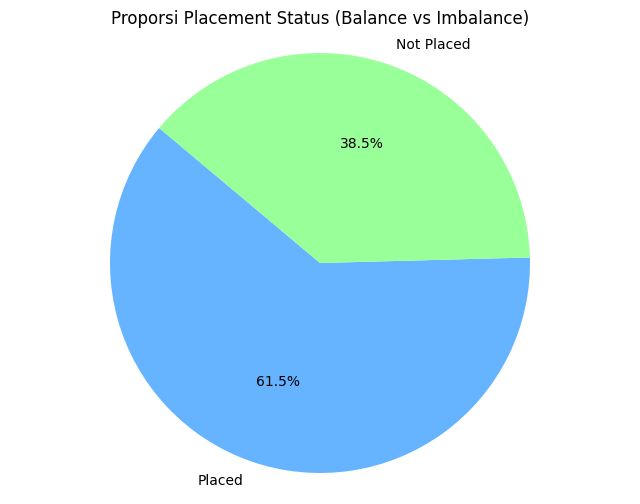

In [99]:
plt.figure(figsize=(8, 6))
# Menghitung distribusi kelas pada placement_status
placement_counts = df['placement_status'].value_counts()
plt.pie(placement_counts, labels=placement_counts.index, autopct='%1.1f%%', 
        colors=['#66b3ff','#99ff99'], startangle=140)
plt.title('Proporsi Placement Status (Balance vs Imbalance)')
plt.axis('equal') 
plt.show()

##### 2.2.2. Visualisasi Identifikasi Outlier pada Tiap Kolom

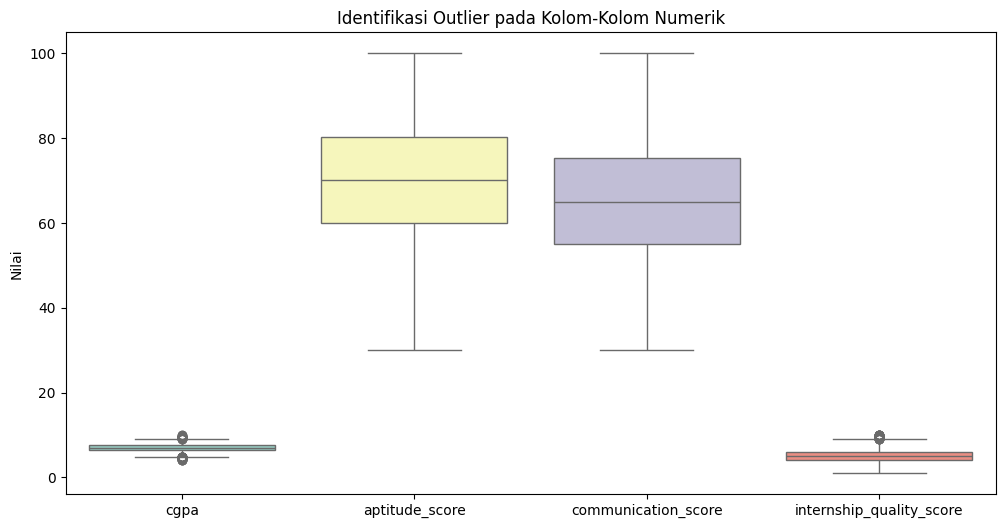

In [100]:
plt.figure(figsize=(12, 6))
# Memilih variabel numerik utama untuk melihat outlier menggunakan Boxplot
numerical_cols = ['cgpa', 'aptitude_score', 'communication_score', 'internship_quality_score']
sns.boxplot(data=df[numerical_cols], palette='Set3')
plt.title('Identifikasi Outlier pada Kolom-Kolom Numerik')
plt.ylabel('Nilai')
plt.show()

##### 2.2.3. Visualisasi Korelasi Kolom Kategorikal dengan Kelas Target

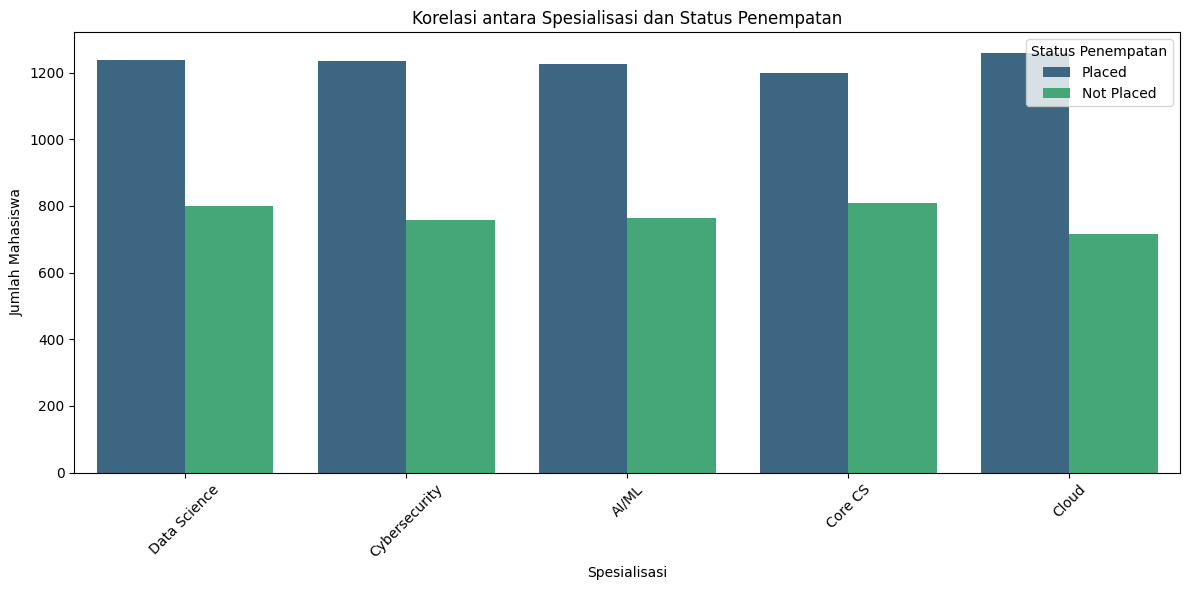

In [101]:
plt.figure(figsize=(12, 6))
# Melihat hubungan antara 'specialization' dengan target 'placement_status'
sns.countplot(x='specialization', hue='placement_status', data=df, palette='viridis')
plt.title('Korelasi antara Spesialisasi dan Status Penempatan')
plt.xlabel('Spesialisasi')
plt.ylabel('Jumlah Mahasiswa')
plt.xticks(rotation=45)
plt.legend(title='Status Penempatan')
plt.tight_layout()
plt.show()

### 3. Data Cleaning & Preprocessing

In [102]:
TARGET_COL = 'placement_status'
ID_COL     = None 

# Mengambil kolom dengan tipe data 'object' sebagai kategorikal
CAT_COLS = ['college_tier', 'country', 'university_ranking_band', 'specialization', 'industry']

# Mengambil sisa kolom sebagai numerik
NUM_COLS = [c for c in df.columns if c not in CAT_COLS + [TARGET_COL] + ([ID_COL] if ID_COL else [])]

print("Categorical:", CAT_COLS)
print("Numerical:  ", NUM_COLS)

# Buat salinan sesuai referensi
train = train_df.copy()
test  = test_df.copy()

print(f"\nData berhasil dipisahkan:")
print(f"Jumlah baris Data Train: {len(train)}")
print(f"Jumlah baris Data Test : {len(test)}")

Categorical: ['college_tier', 'country', 'university_ranking_band', 'specialization', 'industry']
Numerical:   ['cgpa', 'backlogs', 'internship_count', 'aptitude_score', 'communication_score', 'internship_quality_score']

Data berhasil dipisahkan:
Jumlah baris Data Train: 3000
Jumlah baris Data Test : 7000


#### 3.1. Handling Missing Value 

In [103]:
print(f"Otomatis mendeteksi: {len(NUM_COLS)} kolom Numerik dan {len(CAT_COLS)} kolom Kategorikal.")

if NUM_COLS:
    num_imputer = SimpleImputer(strategy='median')
    train[NUM_COLS] = num_imputer.fit_transform(train[NUM_COLS])
    test[NUM_COLS]  = num_imputer.transform(test[NUM_COLS])
    print("Imputasi Numerik (Median) selesai.")

if CAT_COLS:
    cat_imputer = SimpleImputer(strategy='most_frequent')
    train[CAT_COLS] = cat_imputer.fit_transform(train[CAT_COLS])
    test[CAT_COLS]  = cat_imputer.transform(test[CAT_COLS])
    print("Imputasi Kategorikal (Modus) selesai.")

print(f"Missing values di Train: {train.isnull().sum().sum()}")

Otomatis mendeteksi: 6 kolom Numerik dan 5 kolom Kategorikal.
Imputasi Numerik (Median) selesai.
Imputasi Kategorikal (Modus) selesai.
Missing values di Train: 0


#### 3.2. Handling Outliers

In [104]:
outlier_summary = {}

# Metode 1: IQR dengan Clipping (digunakan dalam praktik)
for col in NUM_COLS:
    Q1 = train[col].quantile(0.25)
    Q3 = train[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers_count = ((train[col] < lower_bound) | (train[col] > upper_bound)).sum()
    outlier_summary[col] = {'outliers_detected': outliers_count, 'lower': lower_bound, 'upper': upper_bound}
    
    print(f" - {col:30s}: {outliers_count:3d} outlier (bounds: [{lower_bound:.2f}, {upper_bound:.2f}])")

    # Clipping data train dan test menggunakan bound dari train
    train[col] = train[col].clip(lower=lower_bound, upper=upper_bound)
    test[col] = test[col].clip(lower=lower_bound, upper=upper_bound)


 - cgpa                          :  22 outlier (bounds: [4.86, 9.15])
 - backlogs                      :  12 outlier (bounds: [-3.00, 5.00])
 - internship_count              : 187 outlier (bounds: [-0.50, 3.50])
 - aptitude_score                :   0 outlier (bounds: [29.56, 111.17])
 - communication_score           :   0 outlier (bounds: [24.72, 105.18])
 - internship_quality_score      :  15 outlier (bounds: [0.98, 9.05])


#### 3.3. Encode Fitur Kategorikal

In [105]:
train = pd.get_dummies(train, columns=CAT_COLS, drop_first=True)
test = pd.get_dummies(test, columns=CAT_COLS, drop_first=True)

valid_cols = [c for c in train.columns if c != ID_COL]
test = test.reindex(columns=valid_cols, fill_value=0)

#### 3.4. Feature Scalling 

In [106]:
scaler = StandardScaler()

# Fit pada training data SAJA - avoid data leakage
train[NUM_COLS] = scaler.fit_transform(train[NUM_COLS])
# Transform test data menggunakan parameter yang sudah fitted
test[NUM_COLS] = scaler.transform(test[NUM_COLS])

#### 3.5. Feature Engineering

In [107]:
def create_features(df):
    df['total_assessment_score'] = df['aptitude_score'] + df['communication_score']

    # Menghitung bobot pengalaman magang (kuantitas x kualitas)
    df['internship_experience_index'] = df['internship_count'] * df['internship_quality_score']

    # Rasio kegagalan (backlog) terhadap IPK. 
    # Ditambah 1 pada penyebut untuk menghindari pembagian dengan nol.
    df['academic_risk_ratio'] = df['backlogs'] / (df['cgpa'] + 1)

    # Rata-rata dari semua nilai tes yang tersedia
    df['average_test_score'] = df[['aptitude_score', 'communication_score', 'internship_quality_score']].mean(axis=1)

    # Menandai mahasiswa yang punya CGPA > 8.0 DAN tidak punya backlog
    df['is_high_achiever'] = ((df['cgpa'] > 8.0) & (df['backlogs'] == 0)).astype(int)

    # Interaksi antara Aptitude dan CGPA (mengasumsikan kecerdasan akademik berkorelasi dengan logika)
    df['technical_power'] = df['aptitude_score'] * df['cgpa']
    print("Fitur baru berhasil ditambahkan!")
    print(df[['total_assessment_score', 'internship_experience_index', 'academic_risk_ratio', 'is_high_achiever']].head())
    return df

train = create_features(train)
test = create_features(test)

Fitur baru berhasil ditambahkan!
      total_assessment_score  internship_experience_index  \
5525                0.120134                    -1.642338   
771                 1.814832                    -0.413586   
7839                1.104486                    -0.678463   
2395                1.135738                    -1.168920   
1478               -0.176238                    -0.432447   

      academic_risk_ratio  is_high_achiever  
5525             1.640039                 0  
771             -2.477717                 0  
7839            -0.350930                 0  
2395            -3.427509                 0  
1478            -9.265520                 0  
Fitur baru berhasil ditambahkan!
      total_assessment_score  internship_experience_index  \
6252                1.840162                     0.253132   
4684                0.143648                    -0.306792   
1731               -1.431381                    -1.774729   
4742                3.271253                   

### 4. Model & Validation
#### 4.1. Model FFNN Scikit

In [108]:
import warnings
warnings.filterwarnings('ignore')

# TARGET ENCODING - KONVERSI KATEGORIKAL KE NUMERIK
if train[TARGET_COL].dtype == 'object':
    train[TARGET_COL] = train[TARGET_COL].map({'Placed': 1, 'Not Placed': 0})
    test[TARGET_COL] = test[TARGET_COL].map({'Placed': 1, 'Not Placed': 0})

# PERSIAPAN DATA - AVOID DATA LEAKAGE
X_train = train.drop(columns=[TARGET_COL])
y_train = train[TARGET_COL]

X_test = test.drop(columns=[TARGET_COL])
y_test = test[TARGET_COL]

if ID_COL and ID_COL in X_train.columns:
    X_train = X_train.drop(columns=[ID_COL])
    X_test = X_test.drop(columns=[ID_COL])

# Macro F1 Scorer
from sklearn.metrics import make_scorer, f1_score, classification_report, confusion_matrix
macro_f1_scorer = make_scorer(f1_score, average='macro')


best_model = MLPClassifier(
    activation="logistic",
    alpha=0.01,
    hidden_layer_sizes=(128, 64),
    learning_rate_init=0.01,
    max_iter=1000,           # Increased max iterations
    random_state=42,
    solver='adam',           # Use adam optimizer untuk stabilitas
    batch_size=32,           # Mini-batch size
    tol=1e-4,                # Tolerance for optimization
    verbose=0
)

best_model.fit(X_train, y_train)

,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(128, ...)"
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'logistic'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'adam'
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.For an example usage and visualization of varying regularization, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_alpha.py`.",0.01
,"batch_size batch_size: int, default='auto'Size of minibatches for stochastic optimizers.If the solver is 'lbfgs', the classifier will not use minibatch.When set to ""auto"", `batch_size=min(200, n_samples)`.",32
,"learning_rate learning_rate: {'constant', 'invscaling', 'adaptive'}, default='constant'Learning rate schedule for weight updates.- 'constant' is a constant learning rate given by 'learning_rate_init'.- 'invscaling' gradually decreases the learning rate at each time step 't' using an inverse scaling exponent of 'power_t'. effective_learning_rate = learning_rate_init / pow(t, power_t)- 'adaptive' keeps the learning rate constant to 'learning_rate_init' as long as training loss keeps decreasing. Each time two consecutive epochs fail to decrease training loss by at least tol, or fail to increase validation score by at least tol if 'early_stopping' is on, the current learning rate is divided by 5.Only used when ``solver='sgd'``.",'constant'
,"learning_rate_init learning_rate_init: float, default=0.001The initial learning rate used. It controls the step-sizein updating the weights. Only used when solver='sgd' or 'adam'.",0.01
,"power_t power_t: float, default=0.5The exponent for inverse scaling learning rate.It is used in updating effective learning rate when the learning_rateis set to 'invscaling'. Only used when solver='sgd'.",0.5
,"max_iter max_iter: int, default=200Maximum number of iterations. The solver iterates until convergence(determined by 'tol') or this number of iterations. For stochasticsolvers ('sgd', 'adam'), note that this determines the number of epochs(how many times each data point will be used), not the number ofgradient steps.",1000
,"shuffle shuffle: bool, default=TrueWhether to shuffle samples in each iteration. Only used whensolver='sgd' or 'adam'.",True
,"random_state random_state: int, RandomState instance, default=NoneDetermines random number generation for weights and biasinitialization, train-test split if early stopping is used, and batchsampling when solver='sgd' or 'adam'.Pass an int for reproducible results across multiple function calls.See :term:`Glossary `.",42


In [109]:
# PREDIKSI PADA TRAIN SET
y_pred_train = best_model.predict(X_train)
y_pred_test = best_model.predict(X_test)

train_macro_f1 = f1_score(y_train, y_pred_train, average='macro')
test_macro_f1 = f1_score(y_test, y_pred_test, average='macro')
train_accuracy = accuracy_score(y_train, y_pred_train)
test_accuracy = accuracy_score(y_test, y_pred_test)

print("AKURASI MODEL PADA TRAIN SET")
print(f"Train Accuracy:     {train_accuracy:.4f}")
print(f"Train Macro F1:     {train_macro_f1:.4f}")

print("AKURASI MODEL PADA TEST SET (FINAL)")
print(f"Test Accuracy:      {test_accuracy:.4f}")
print(f"Test Macro F1:      {test_macro_f1:.4f}")

print("HASIL KLASIFIKASI (TEST SET)")
print(classification_report(y_test, y_pred_test, 
                          target_names=['Not Placed', 'Placed'],
                          digits=4))

# Deteksi overfitting/underfitting
if train_macro_f1 - test_macro_f1 > 0.05:
    print(f"\n⚠ Warning: Potential Overfitting detected (Train F1: {train_macro_f1:.4f} >> Test F1: {test_macro_f1:.4f})")
elif test_macro_f1 - train_macro_f1 > 0.05:
    print(f"\n⚠ Warning: Potential Underfitting detected (Test F1: {test_macro_f1:.4f} >> Train F1: {train_macro_f1:.4f})")
else:
    print(f"\n✓ Generalization: Model shows good generalization (Diff: {abs(train_macro_f1 - test_macro_f1):.4f})")


AKURASI MODEL PADA TRAIN SET
Train Accuracy:     0.7363
Train Macro F1:     0.7192
AKURASI MODEL PADA TEST SET (FINAL)
Test Accuracy:      0.7573
Test Macro F1:      0.7405
HASIL KLASIFIKASI (TEST SET)
              precision    recall  f1-score   support

  Not Placed     0.6940    0.6560    0.6745      2683
      Placed     0.7932    0.8202    0.8065      4317

    accuracy                         0.7573      7000
   macro avg     0.7436    0.7381    0.7405      7000
weighted avg     0.7552    0.7573    0.7559      7000


✓ Generalization: Model shows good generalization (Diff: 0.0213)


In [110]:
# CONFUSION MATRIX
cm = confusion_matrix(y_test, y_pred_test)
print("\n" + "="*70)
print("CONFUSION MATRIX (TEST SET)")
print("="*70)
print(f"True Negatives:  {cm[0,0]}")
print(f"False Positives: {cm[0,1]}")
print(f"False Negatives: {cm[1,0]}")
print(f"True Positives:  {cm[1,1]}")


CONFUSION MATRIX (TEST SET)
True Negatives:  1760
False Positives: 923
False Negatives: 776
True Positives:  3541


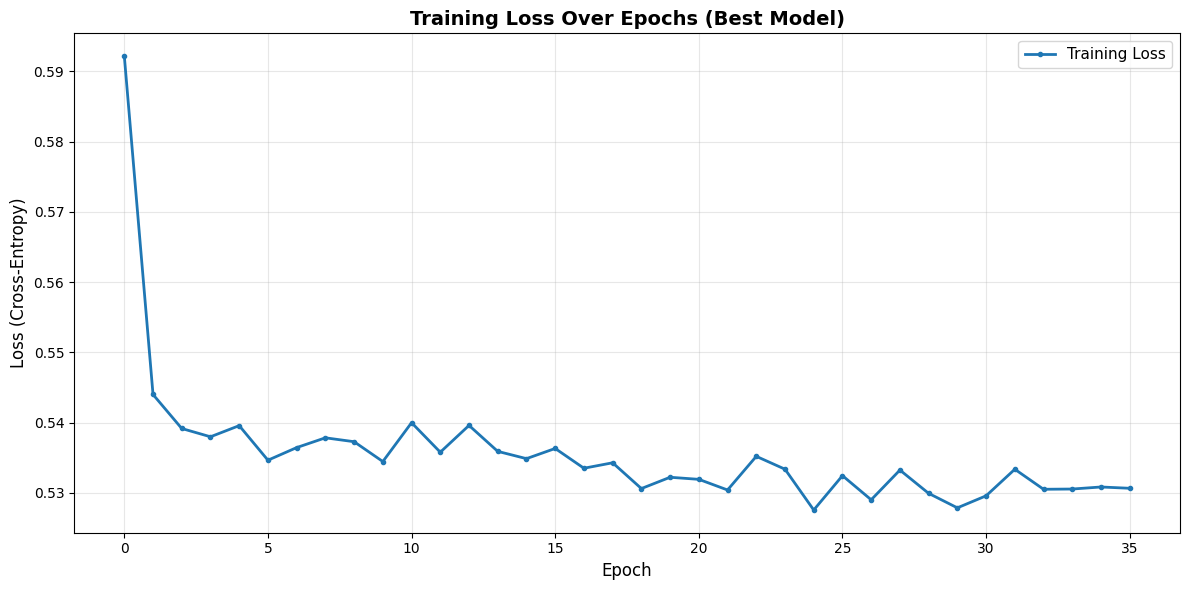


LOSS CURVE INSIGHTS
Minimum Loss: 0.527551 at Epoch 25
Initial Loss: 0.592188
Final Loss:   0.530646
Total Epochs: 36


In [111]:
# Extract loss curve dari best model
loss_curve = best_model.loss_curve_

# Buat plot loss curve
plt.figure(figsize=(12, 6))
plt.plot(loss_curve, linewidth=2, marker='o', markersize=3, label='Training Loss')
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss (Cross-Entropy)', fontsize=12)
plt.title('Training Loss Over Epochs (Best Model)', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

min_loss = min(loss_curve)
min_loss_epoch = np.argmin(loss_curve)
print(f"\n" + "="*70)
print("LOSS CURVE INSIGHTS")
print("="*70)
print(f"Minimum Loss: {min_loss:.6f} at Epoch {min_loss_epoch + 1}")
print(f"Initial Loss: {loss_curve[0]:.6f}")
print(f"Final Loss:   {loss_curve[-1]:.6f}")
print(f"Total Epochs: {len(loss_curve)}")

### 4.2. Model FFNN Algorithm
Bagian ini menambahkan pengujian model `FFNN` dari folder `src/Algorithm` agar bisa dibandingkan dengan model Scikit-learn.

In [112]:
import sys
from pathlib import Path
import importlib

# Tambahkan path src/Algorithm agar modul custom bisa diimport
cwd = Path.cwd().resolve()
algo_dir_candidates = [
    cwd / 'src' / 'Algorithm',
    (cwd / '..' / 'Algorithm').resolve(),
]
algo_dir = next((p for p in algo_dir_candidates if p.exists()), None)

if algo_dir is None:
    raise FileNotFoundError('Folder src/Algorithm tidak ditemukan dari working directory notebook saat ini.')

if str(algo_dir) not in sys.path:
    sys.path.append(str(algo_dir))

import autodiff
import optimizer
import ffnn

importlib.reload(autodiff)
importlib.reload(optimizer)
ffnn = importlib.reload(ffnn)

FFNN = ffnn.FFNN

# Pastikan array numerik agar kompatibel dengan operasi numpy di Algorithm
X_train_np = X_train.to_numpy(dtype=float) if hasattr(X_train, 'to_numpy') else np.asarray(X_train, dtype=float)
X_test_np = X_test.to_numpy(dtype=float) if hasattr(X_test, 'to_numpy') else np.asarray(X_test, dtype=float)
y_train_np = (y_train.to_numpy() if hasattr(y_train, 'to_numpy') else np.asarray(y_train))
y_test_np = (y_test.to_numpy() if hasattr(y_test, 'to_numpy') else np.asarray(y_test))

ffnn_custom = FFNN(
    hidden_layer_sizes=[128, 64],
    hidden_layer_activations=['sigmoid', 'sigmoid'],
    output_layer_activation='softmax',
    loss_function='cce',
    weight_initialization='normal',
    mean=0.0,
    variance=0.05,
    random_seed=42,
    batch_size=32,
    epochs=300,
    optimizer='gd',
    learning_rate=0.01,
    verbose=True,
)

ffnn_custom.fit(X_train_np, y_train_np)
y_pred_train_custom = ffnn_custom.predict(X_train_np)
y_pred_test_custom = ffnn_custom.predict(X_test_np)

custom_train_acc = accuracy_score(y_train_np, y_pred_train_custom)
custom_test_acc = accuracy_score(y_test_np, y_pred_test_custom)
custom_train_f1 = f1_score(y_train_np, y_pred_train_custom, average='macro')
custom_test_f1 = f1_score(y_test_np, y_pred_test_custom, average='macro')

print('=' * 70)
print('HASIL FFNN CUSTOM (ALGORITHM)')
print('=' * 70)
print(f'Train Accuracy: {custom_train_acc:.4f}')
print(f'Test Accuracy : {custom_test_acc:.4f}')
print(f'Train Macro F1: {custom_train_f1:.4f}')
print(f'Test Macro F1 : {custom_test_f1:.4f}')

print('\nClassification Report (Custom FFNN - Test):')
print(classification_report(y_test_np, y_pred_test_custom, target_names=['Not Placed', 'Placed'], digits=4))

Starting training with 3000 samples, 29 features, 2 labels
Weights and biases initialized with 12226 parameters
Optimizers initialized
Computation graph built
Training data scrambled
Epoch 1/300
  Batch loss: 1.0494687703273522
Epoch 2/300
  Batch loss: 1.134967767786396
Epoch 3/300
  Batch loss: 0.9190417691888175
Epoch 4/300
  Batch loss: 0.7450579762098981
Epoch 5/300
  Batch loss: 0.642638834690811
Epoch 6/300
  Batch loss: 0.8706904307806532
Epoch 7/300
  Batch loss: 0.7666973912910966
Epoch 8/300
  Batch loss: 1.232864602891636
Epoch 9/300
  Batch loss: 0.91840672566828
Epoch 10/300
  Batch loss: 0.9161970432825998
Epoch 11/300
  Batch loss: 1.5701440633705563
Epoch 12/300
  Batch loss: 1.256011712247025
Epoch 13/300
  Batch loss: 1.1939734359878873
Epoch 14/300
  Batch loss: 0.7289325327011091
Epoch 15/300
  Batch loss: 0.741858726474221
Epoch 16/300
  Batch loss: 0.6108766551634314
Epoch 17/300
  Batch loss: 0.6735868331176134
Epoch 18/300
  Batch loss: 0.6749626732868993
Epoch

In [113]:
# Uji save/load weights model custom
custom_weight_path = '../../dataset/custom_ffnn_weights.npz'
ffnn_custom.save(custom_weight_path)

ffnn_custom_loaded = FFNN.load(custom_weight_path)
y_pred_loaded = ffnn_custom_loaded.predict(X_test_np)

same_prediction = np.array_equal(y_pred_loaded, y_pred_test_custom)
print('=' * 70)
print('VALIDASI SAVE/LOAD WEIGHTS CUSTOM FFNN')
print('=' * 70)
print(f'Path file bobot: {custom_weight_path}')
print(f'Prediksi sama sebelum/sesudah load: {same_prediction}')

VALIDASI SAVE/LOAD WEIGHTS CUSTOM FFNN
Path file bobot: ../../dataset/custom_ffnn_weights.npz
Prediksi sama sebelum/sesudah load: True
